# **Abstractive Text Summarization using Seq2Seq with Attention (Document Intelligence and Summarization System)**

### **Project Objective**

The objective of this project is to develop an **Abstractive Text Summarization System** using **Sequence-to-Sequence (Seq2Seq) LSTM Networks with Attention Mechanism** to generate concise and meaningful summaries of long textual documents.

In many real-world scenarios, large volumes of text data make it difficult to extract key information efficiently. This project focuses on building a deep learning model capable of understanding the context of a document and generating human-like summaries.

The system is designed to:

- Generate **concise summaries from long text documents**  
- Capture **context and semantic meaning of text**  
- Learn **language generation using Seq2Seq architecture**  
- Improve summarization quality using **attention mechanisms**  

This project is highly applicable in:
- news summarization systems  
- document analysis tools  
- research paper summarization  
- content recommendation platforms  

### **Dataset Used**

This project utilizes datasets containing documents and their corresponding summaries.

### **Dataset Sources**

- **CNN/DailyMail Dataset** *(commonly used for summarization tasks)*  
- Other summarization datasets *(as used in your notebook)*  

### **Dataset Characteristics**

The dataset includes:

- **Input text**:
  - long documents or articles  

- **Target output**:
  - human-written summaries  

Key characteristics:
- sequence-to-sequence text data  
- large vocabulary  
- varying document lengths  

### **How Dataset is Used in the Project**

The dataset is processed through a text summarization pipeline:

- **Text preprocessing**
  - cleaning and normalization  
  - tokenization  
  - vocabulary creation  

- **Sequence preparation**
  - converting documents and summaries into sequences  
  - padding sequences  

- **Train-test split**
  - ensures evaluation  

- **Model training**
  - encoder processes input text  
  - decoder generates summary  

The dataset enables the model to learn **content compression and abstraction**, which are essential for summarization.




### **Import Core Libraries:**

In [1]:
import os
import json
import random
import re
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

try:
    import tensorflow as tf
except ImportError:
    raise ImportError("TensorFlow is not installed. Please run: pip install tensorflow")

from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

### **Reproducibility Setup:**

In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
print("Seed fixed at:", SEED)

Seed fixed at: 42


### **Create Project Folders:**

In [3]:
BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / "data_lstm_summarization"
ARTIFACT_DIR = BASE_DIR / "artifacts_lstm_summarization"
MODEL_DIR = ARTIFACT_DIR / "models"
PLOT_DIR = ARTIFACT_DIR / "plots"
for folder in [DATA_DIR, ARTIFACT_DIR, MODEL_DIR, PLOT_DIR]:
    folder.mkdir(parents=True, exist_ok=True)
print(DATA_DIR)
print(ARTIFACT_DIR)

C:\Users\atripathi\OneDrive - Veralto\Desktop\AI Codes\RNN\LSTM Model\Text Summarization using Seq2Seq with Attention\data_lstm_summarization
C:\Users\atripathi\OneDrive - Veralto\Desktop\AI Codes\RNN\LSTM Model\Text Summarization using Seq2Seq with Attention\artifacts_lstm_summarization


### **Load or Generate Summarization Dataset:**

In [4]:
def generate_summarization_dataset(n=2500, seed=42):
    rng = np.random.default_rng(seed)
    subjects = ["company", "government", "research team", "hospital", "startup", "city council", "university", "energy provider"]
    actions = ["announced", "reported", "launched", "confirmed", "investigated", "expanded", "approved", "published"]
    themes = ["new policy", "product release", "clinical study", "funding round", "service disruption", "sustainability plan", 
              "safety update", "technology roadmap"]
    impacts = ["improving operations", "reducing costs", "supporting citizens", "expanding access", "strengthening compliance", 
               "improving outcomes", "accelerating deployment", "boosting efficiency"]
    rows = []
    for _ in range(n):
        s = rng.choice(subjects)
        a = rng.choice(actions)
        t = rng.choice(themes)
        i = rng.choice(impacts)
        detail1 = f"The {s} {a} a {t} after several months of internal review and consultation with stakeholders."
        detail2 = f"Officials said the decision is expected to help with {i} over the next few quarters."
        detail3 = f"Additional commentary noted that implementation will happen in phases and that teams will monitor risks closely."
        article = " ".join([detail1, detail2, detail3])
        summary = f"{s} {a} a {t} to support {i}."
        rows.append({"article": article, "summary": summary})
    return pd.DataFrame(rows), "synthetic_fallback"

def load_summarization_data():
    local_candidates = [
        DATA_DIR / "summaries.csv",
        DATA_DIR / "cnn_dailymail_sample.csv",
        BASE_DIR / "summaries.csv",
        BASE_DIR / "cnn_dailymail_sample.csv"
    ]
    for path in local_candidates:
        if path.exists():
            try:
                return pd.read_csv(path), f"local_file:{path.name}"
            except Exception as e:
                print(f"Could not read {path}: {e}")
    return generate_summarization_dataset(seed=SEED)

df, data_source = load_summarization_data()
print("Data source used:", data_source)
print(df.shape)
df.head()

Data source used: synthetic_fallback
(2500, 2)


,article,summary
0,The company approved a sustainability plan aft...,company approved a sustainability plan to supp...
1,The hospital approved a new policy after sever...,hospital approved a new policy to support impr...
2,The government announced a service disruption ...,government announced a service disruption to s...
3,The city council approved a sustainability pla...,city council approved a sustainability plan to...
4,The startup reported a safety update after sev...,startup reported a safety update to support ex...


### **Initial Inspection:**

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   article  2500 non-null   str  
 1   summary  2500 non-null   str  
dtypes: str(2)
memory usage: 1021.2 KB


### **Missing Value Check:**

In [6]:
missing_df = df.isna().sum().sort_values(ascending=False).to_frame("missing_count")
missing_df["missing_pct"] = (missing_df["missing_count"] / len(df) * 100).round(3)
missing_df

,missing_count,missing_pct
article,0,0.0
summary,0,0.0


### **Keep Required Columns:**

In [7]:
df = df[["article", "summary"]].dropna().reset_index(drop=True)
df.head()

,article,summary
0,The company approved a sustainability plan aft...,company approved a sustainability plan to supp...
1,The hospital approved a new policy after sever...,hospital approved a new policy to support impr...
2,The government announced a service disruption ...,government announced a service disruption to s...
3,The city council approved a sustainability pla...,city council approved a sustainability plan to...
4,The startup reported a safety update after sev...,startup reported a safety update to support ex...


### **Text Cleaning Helper:**

In [8]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

### **Clean Article Text:**

In [9]:
df["article_clean"] = df["article"].apply(clean_text)
df[["article", "article_clean"]].head()

,article,article_clean
0,The company approved a sustainability plan aft...,the company approved a sustainability plan aft...
1,The hospital approved a new policy after sever...,the hospital approved a new policy after sever...
2,The government announced a service disruption ...,the government announced a service disruption ...
3,The city council approved a sustainability pla...,the city council approved a sustainability pla...
4,The startup reported a safety update after sev...,the startup reported a safety update after sev...


### **Clean Summary Text:**

In [10]:
df["summary_clean"] = df["summary"].apply(clean_text)
df[["summary", "summary_clean"]].head()

,summary,summary_clean
0,company approved a sustainability plan to supp...,company approved a sustainability plan to supp...
1,hospital approved a new policy to support impr...,hospital approved a new policy to support impr...
2,government announced a service disruption to s...,government announced a service disruption to s...
3,city council approved a sustainability plan to...,city council approved a sustainability plan to...
4,startup reported a safety update to support ex...,startup reported a safety update to support ex...


### **Add Start and End Tokens to Summary:**

In [11]:
df["summary_seq"] = df["summary_clean"].apply(lambda x: "sostok " + x + " eostok")
df[["summary_clean", "summary_seq"]].head()

,summary_clean,summary_seq
0,company approved a sustainability plan to supp...,sostok company approved a sustainability plan ...
1,hospital approved a new policy to support impr...,sostok hospital approved a new policy to suppo...
2,government announced a service disruption to s...,sostok government announced a service disrupti...
3,city council approved a sustainability plan to...,sostok city council approved a sustainability ...
4,startup reported a safety update to support ex...,sostok startup reported a safety update to sup...


### **Text Length Analysis:**

In [12]:
df["article_len"] = df["article_clean"].str.split().apply(len)
df["summary_len"] = df["summary_clean"].str.split().apply(len)
df[["article_len", "summary_len"]].describe()

,article_len,summary_len
count,2500.000000,2500.000000
mean,48.369200,9.369200
std,0.482685,0.482685
min,48.000000,9.000000
25%,48.000000,9.000000
50%,48.000000,9.000000
75%,49.000000,10.000000
max,49.000000,10.000000


### **Plot Article Length Distribution:**

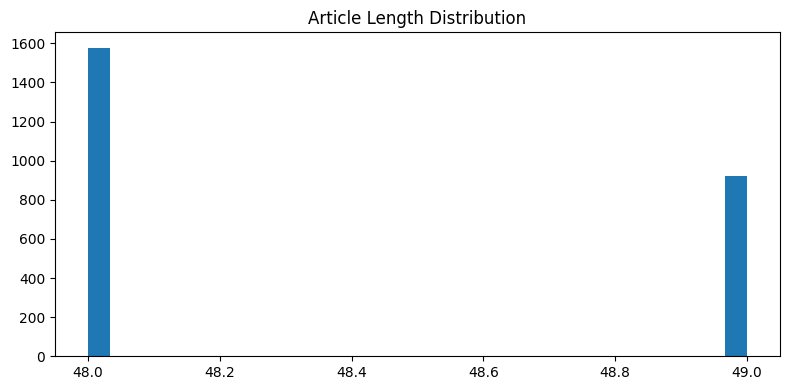

In [13]:
plt.figure(figsize=(8, 4)); plt.hist(df["article_len"], bins=30); plt.title("Article Length Distribution"); plt.tight_layout(); plt.show()

### **Plot Summary Length Distribution:**

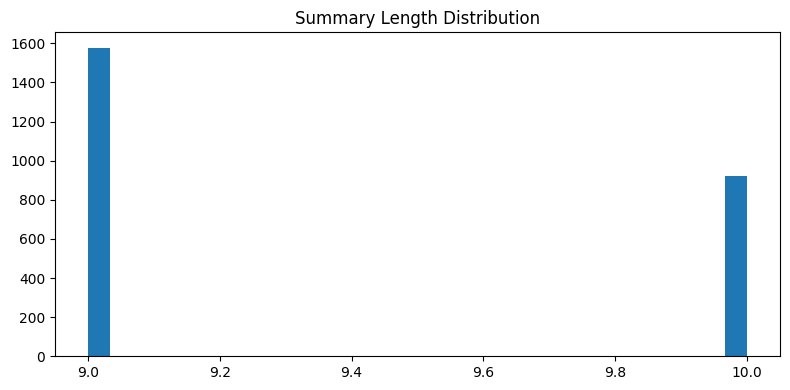

In [14]:
plt.figure(figsize=(8, 4)); plt.hist(df["summary_len"], bins=30); plt.title("Summary Length Distribution"); plt.tight_layout(); plt.show()

### **Apply Length Filters:**

In [15]:
MAX_ARTICLE_WORDS = int(np.percentile(df["article_len"], 95))
MAX_SUMMARY_WORDS = int(np.percentile(df["summary_len"], 95))
df_filtered = df[(df["article_len"] <= MAX_ARTICLE_WORDS) & (df["summary_len"] <= MAX_SUMMARY_WORDS)].copy().reset_index(drop=True)
print(df_filtered.shape)

(2500, 7)


### **Train / Validation / Test Split:**

In [16]:
train_df, temp_df = train_test_split(df_filtered, test_size=0.30, random_state=SEED)
val_df, test_df = train_test_split(temp_df, test_size=0.50, random_state=SEED)
print(train_df.shape, val_df.shape, test_df.shape)

(1750, 7) (375, 7) (375, 7)


### **Fit Source Tokenizer:**

In [17]:
src_tokenizer = Tokenizer(oov_token="<unk>"); src_tokenizer.fit_on_texts(train_df["article_clean"]); 
src_vocab_size = len(src_tokenizer.word_index) + 1; print("Source vocab size:", src_vocab_size)

Source vocab size: 88


### **Fit Target Tokenizer:**

In [18]:
tgt_tokenizer = Tokenizer(oov_token="<unk>"); 
tgt_tokenizer.fit_on_texts(train_df["summary_seq"]); 
tgt_vocab_size = len(tgt_tokenizer.word_index) + 1; print("Target vocab size:", tgt_vocab_size)

Target vocab size: 57


### **Convert Source Text to Sequences:**

In [19]:
X_train_seq = src_tokenizer.texts_to_sequences(train_df["article_clean"]); 
X_val_seq = src_tokenizer.texts_to_sequences(val_df["article_clean"]); 
X_test_seq = src_tokenizer.texts_to_sequences(test_df["article_clean"]); 
len(X_train_seq), len(X_val_seq), len(X_test_seq)

(1750, 375, 375)

### **Convert Target Text to Sequences:**

In [20]:
y_train_seq = tgt_tokenizer.texts_to_sequences(train_df["summary_seq"]); 
y_val_seq = tgt_tokenizer.texts_to_sequences(val_df["summary_seq"]); 
y_test_seq = tgt_tokenizer.texts_to_sequences(test_df["summary_seq"]); 
len(y_train_seq), len(y_val_seq), len(y_test_seq)

(1750, 375, 375)

### **Pad Source Sequences:**

In [21]:
MAX_SRC_LEN = min(MAX_ARTICLE_WORDS + 2, max(len(x) for x in X_train_seq))
MAX_TGT_LEN = min(MAX_SUMMARY_WORDS + 4, max(len(x) for x in y_train_seq))
X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_SRC_LEN, padding="post")
X_val_pad = pad_sequences(X_val_seq, maxlen=MAX_SRC_LEN, padding="post")
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_SRC_LEN, padding="post")
print(X_train_pad.shape)

(1750, 49)


### **Pad Target Sequences:**

In [22]:
y_train_pad = pad_sequences(y_train_seq, maxlen=MAX_TGT_LEN, padding="post"); 
y_val_pad = pad_sequences(y_val_seq, maxlen=MAX_TGT_LEN, padding="post"); 
y_test_pad = pad_sequences(y_test_seq, maxlen=MAX_TGT_LEN, padding="post"); print(y_train_pad.shape)

(1750, 12)


### **Build Decoder Inputs and Targets:**

In [23]:
decoder_input_train = y_train_pad[:, :-1]; decoder_target_train = y_train_pad[:, 1:]; 
decoder_input_val = y_val_pad[:, :-1]; decoder_target_val = y_val_pad[:, 1:]; 
decoder_input_test = y_test_pad[:, :-1]; decoder_target_test = y_test_pad[:, 1:]; 
print(decoder_input_train.shape, decoder_target_train.shape)

(1750, 11) (1750, 11)


### **Inspect Token Mappings:**

In [24]:
src_index_word = {v:k for k,v in src_tokenizer.word_index.items()}; 
tgt_index_word = {v:k for k,v in tgt_tokenizer.word_index.items()}; print(list(tgt_tokenizer.word_index.items())[:15])

[('<unk>', 1), ('sostok', 2), ('a', 3), ('to', 4), ('support', 5), ('eostok', 6), ('improving', 7), ('reducing', 8), ('costs', 9), ('expanding', 10), ('access', 11), ('product', 12), ('release', 13), ('clinical', 14), ('study', 15)]


### **Sample Sequence Inspection:**

In [25]:
print("Source example:", X_train_pad[0][:20]); print("Target input example:", decoder_input_train[0][:15]); 
print("Target output example:", decoder_target_train[0][:15])

Source example: [ 2 53 54 63  7 57 58  8  9 10 11 12 13  3 14  4 15 16 17  2]
Target input example: [ 2 22 23 32  3 26 27  4  5  7 46]
Target output example: [22 23 32  3 26 27  4  5  7 46  6]


### **BLEU Helper Functions:**

In [26]:
def ngrams(tokens, n):
    return [tuple(tokens[i:i+n]) for i in range(len(tokens)-n+1)]
def simple_bleu(reference, candidate, max_n=2):
    ref_tokens = reference.split()
    cand_tokens = candidate.split()
    if len(cand_tokens) == 0:
        return 0.0
    precisions = []
    for n in range(1, max_n + 1):
        ref_ng = Counter(ngrams(ref_tokens, n))
        cand_ng = Counter(ngrams(cand_tokens, n))
        overlap = sum(min(count, ref_ng[ng]) for ng, count in cand_ng.items())
        total = max(sum(cand_ng.values()), 1)
        precisions.append(overlap / total)
    bp = min(1.0, np.exp(1 - len(ref_tokens) / max(len(cand_tokens), 1)))
    score = bp * np.prod([max(p, 1e-8) for p in precisions]) ** (1 / max_n)
    return float(score)

### **Build Seq2Seq with Attention:**

In [27]:
EMBED_DIM = 128
LATENT_DIM = 128
encoder_inputs = tf.keras.Input(shape=(MAX_SRC_LEN,), name="encoder_inputs")
enc_emb = tf.keras.layers.Embedding(src_vocab_size, EMBED_DIM, mask_zero=True, name="encoder_embedding")(encoder_inputs)
encoder_lstm = tf.keras.layers.LSTM(LATENT_DIM, return_sequences=True, return_state=True, name="encoder_lstm")
encoder_outputs, state_h, state_c = encoder_lstm(enc_emb)

decoder_inputs = tf.keras.Input(shape=(MAX_TGT_LEN - 1,), name="decoder_inputs")
dec_emb_layer = tf.keras.layers.Embedding(tgt_vocab_size, EMBED_DIM, mask_zero=True, name="decoder_embedding")
dec_emb = dec_emb_layer(decoder_inputs)
decoder_lstm = tf.keras.layers.LSTM(LATENT_DIM, return_sequences=True, return_state=True, name="decoder_lstm")
decoder_outputs, _, _ = decoder_lstm(dec_emb, initial_state=[state_h, state_c])

attention_layer = tf.keras.layers.AdditiveAttention(name="attention_layer")
attention_output = attention_layer([decoder_outputs, encoder_outputs])
concat_layer = tf.keras.layers.Concatenate(axis=-1)
decoder_concat = concat_layer([decoder_outputs, attention_output])

dense_layer = tf.keras.layers.TimeDistributed(tf.keras.layers.Dense(tgt_vocab_size, activation="softmax"), name="time_distributed_output")
decoder_pred = dense_layer(decoder_concat)

seq2seq_model = tf.keras.Model([encoder_inputs, decoder_inputs], decoder_pred)
seq2seq_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
seq2seq_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ encoder_inputs (InputLayer)   │ (None, 49)                │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ decoder_inputs (InputLayer)   │ (None, 11)                │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ encoder_embedding (Embedding) │ (None, 49, 128)           │          11,264 │ encoder_inputs[0][0]       │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ not_equal (NotEqual)          │ (None, 49)                │               0 │ encoder_inputs[0][0]       │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ decoder_embedding (Embedding) │ (None, 11, 128)           │           7,296 │ decoder_inputs[0][0]       │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ encoder_lstm (LSTM)           │ [(None, 49, 128), (None,  │         131,584 │ encoder_embedding[0][0],   │
│                               │ 128), (None, 128)]        │                 │ not_equal[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ decoder_lstm (LSTM)           │ [(None, 11, 128), (None,  │         131,584 │ decoder_embedding[0][0],   │
│                               │ 128), (None, 128)]        │                 │ encoder_lstm[0][1],        │
│                               │                           │                 │ encoder_lstm[0][2]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ not_equal_1 (NotEqual)        │ (None, 11)                │               0 │ decoder_inputs[0][0]       │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ attention_layer               │ (None, 11, 128)           │             128 │ decoder_lstm[0][0],        │
│ (AdditiveAttention)           │                           │                 │ encoder_lstm[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ convert_to_tensor             │ (None, 11)                │               0 │ not_equal_1[0][0]          │
│ (ConvertToTensor)             │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expand_dims (ExpandDims)      │ (None, 11, 1)             │               0 │ not_equal_1[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ zeros_like (ZerosLike)        │ (None, 11, 128)           │               0 │ decoder_lstm[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expand_dims_1 (ExpandDims)    │ (None, 11, 1)             │               0 │ convert_to_tensor[0][0]    │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ zeros_like_1 (ZerosLike)      │ (None, 11, 128)           │               0 │ attention_layer[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ logical_or (LogicalOr)        │ (None, 11, 128)           │               

 Total params: 296,505 (1.13 MB)

 Trainable params: 296,505 (1.13 MB)

 Non-trainable params: 0 (0.00 B)

### **Training Callbacks:**

In [28]:
callbacks = [EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True), 
             ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6)]

### **Train Seq2Seq Model:**

In [29]:
history = seq2seq_model.fit(
    [X_train_pad, decoder_input_train],
    decoder_target_train[..., np.newaxis],
    validation_data=([X_val_pad, decoder_input_val], decoder_target_val[..., np.newaxis]),
    epochs=12,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/12
28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 73ms/step - accuracy: 0.3346 - loss: 3.3698 - val_accuracy: 0.4218 - val_loss: 2.5573 - learning_rate: 0.0010
Epoch 2/12
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step - accuracy: 0.4379 - loss: 2.0991 - val_accuracy: 0.4567 - val_loss: 1.7022 - learning_rate: 0.0010
Epoch 3/12
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step - accuracy: 0.5576 - loss: 1.4740 - val_accuracy: 0.6865 - val_loss: 1.2341 - learning_rate: 0.0010
Epoch 4/12
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - accuracy: 0.7011 - loss: 1.0630 - val_accuracy: 0.7406 - val_loss: 0.9022 - learning_rate: 0.0010
Epoch 5/12
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - accuracy: 0.7333 - loss: 0.8172 - val_accuracy: 0.7581 - val_loss: 0.7440 - learning_rate: 0.0010
Epoch 6/12
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 0.7737 - loss: 0.6815 - val_accuracy: 0.8124 - val_loss: 0.6021 - learning_rate: 0.0010
Epoch 7/12
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - accuracy: 0.8323 - loss: 0.5126 - val_acc

### **Plot Training vs Validation Loss:**

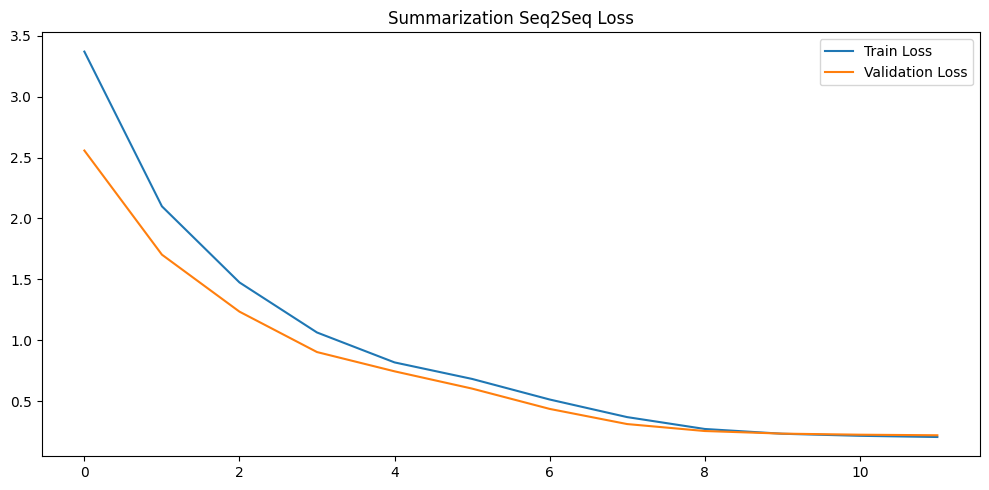

In [30]:
history_df = pd.DataFrame(history.history); plt.figure(figsize=(10, 5)); 
plt.plot(history_df["loss"], label="Train Loss"); plt.plot(history_df["val_loss"], label="Validation Loss"); 
plt.title("Summarization Seq2Seq Loss"); plt.legend(); plt.tight_layout(); plt.show()

### **Plot Training vs Validation Accuracy:**

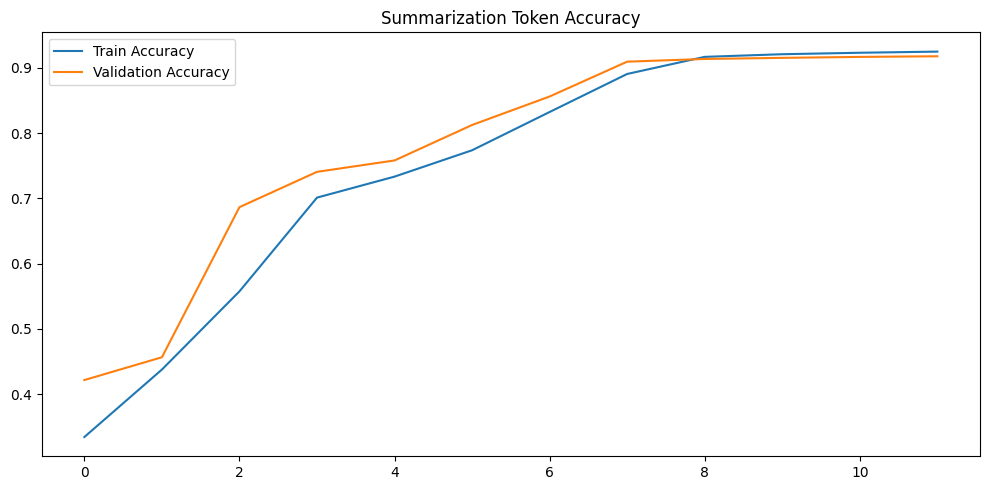

In [31]:
plt.figure(figsize=(10, 5)); plt.plot(history_df["accuracy"], label="Train Accuracy"); 
plt.plot(history_df["val_accuracy"], label="Validation Accuracy"); plt.title("Summarization Token Accuracy"); 
plt.legend(); plt.tight_layout(); plt.show()

### **Build Inference Encoder:**

In [32]:
encoder_model = tf.keras.Model(encoder_inputs, [encoder_outputs, state_h, state_c])

### **Build Inference Decoder Inputs:**

In [33]:
inf_decoder_state_input_h = tf.keras.Input(shape=(LATENT_DIM,)); 
inf_decoder_state_input_c = tf.keras.Input(shape=(LATENT_DIM,)); 
inf_encoder_outputs = tf.keras.Input(shape=(MAX_SRC_LEN, LATENT_DIM)); 
inf_decoder_inputs = tf.keras.Input(shape=(1,))

### **Build Inference Decoder Graph:**

In [34]:
inf_dec_emb = dec_emb_layer(inf_decoder_inputs)
inf_decoder_outputs, inf_state_h, inf_state_c = decoder_lstm(inf_dec_emb, initial_state=[inf_decoder_state_input_h, inf_decoder_state_input_c])
inf_attention_output = attention_layer([inf_decoder_outputs, inf_encoder_outputs])
inf_decoder_concat = concat_layer([inf_decoder_outputs, inf_attention_output])
inf_decoder_pred = dense_layer(inf_decoder_concat)
decoder_model = tf.keras.Model([inf_decoder_inputs, inf_encoder_outputs, 
                                inf_decoder_state_input_h, inf_decoder_state_input_c], [inf_decoder_pred, inf_state_h, inf_state_c])

### **Decode Summary Helper:**

In [35]:
sostok_id = tgt_tokenizer.word_index.get("sostok")
eostok_id = tgt_tokenizer.word_index.get("eostok")
def decode_sequence(input_seq):
    enc_out, h, c = encoder_model.predict(input_seq, verbose=0)
    target_seq = np.array([[sostok_id]])
    decoded_tokens = []
    for _ in range(MAX_TGT_LEN - 1):
        output_tokens, h, c = decoder_model.predict([target_seq, enc_out, h, c], verbose=0)
        sampled_id = int(np.argmax(output_tokens[0, -1, :]))
        if sampled_id == 0 or sampled_id == eostok_id:
            break
        sampled_word = tgt_index_word.get(sampled_id, "")
        if sampled_word not in ["sostok", "eostok", "<unk>"]:
            decoded_tokens.append(sampled_word)
        target_seq = np.array([[sampled_id]])
    return " ".join(decoded_tokens)

### **Generate Validation Predictions:**

In [36]:
val_pred_summaries = [decode_sequence(X_val_pad[i:i+1]) for i in range(min(100, len(X_val_pad)))]; len(val_pred_summaries)

100

### **Generate Test Predictions:**

In [37]:
test_pred_summaries = [decode_sequence(X_test_pad[i:i+1]) for i in range(min(150, len(X_test_pad)))]; len(test_pred_summaries)

150

### **Validation BLEU Approximation:**

In [38]:
val_refs = val_df["summary_clean"].iloc[:len(val_pred_summaries)].tolist(); 
val_bleu_scores = [simple_bleu(r, p) for r, p in zip(val_refs, val_pred_summaries)]; 
print("Validation BLEU-like mean:", round(float(np.mean(val_bleu_scores)), 4))

Validation BLEU-like mean: 0.8147


### **Test BLEU Approximation:**

In [39]:
test_refs = test_df["summary_clean"].iloc[:len(test_pred_summaries)].tolist(); 
test_bleu_scores = [simple_bleu(r, p) for r, p in zip(test_refs, test_pred_summaries)]; 
print("Test BLEU-like mean:", round(float(np.mean(test_bleu_scores)), 4))

Test BLEU-like mean: 0.8063


### **Exact Match Ratio:**

In [40]:
exact_match = np.mean([int(r.strip() == p.strip()) for r, p in zip(test_refs, test_pred_summaries)]); 
print("Exact match ratio:", round(float(exact_match), 4))

Exact match ratio: 0.1267


### **Summary Length Comparison:**

In [41]:
length_df = pd.DataFrame({"reference_len": [len(x.split()) for x in test_refs], 
                          "predicted_len": [len(x.split()) for x in test_pred_summaries]}); length_df.describe()

,reference_len,predicted_len
count,150.000000,150.000000
mean,9.333333,9.333333
std,0.472984,0.472984
min,9.000000,9.000000
25%,9.000000,9.000000
50%,9.000000,9.000000
75%,10.000000,10.000000
max,10.000000,10.000000


### **Plot Reference vs Predicted Length:**

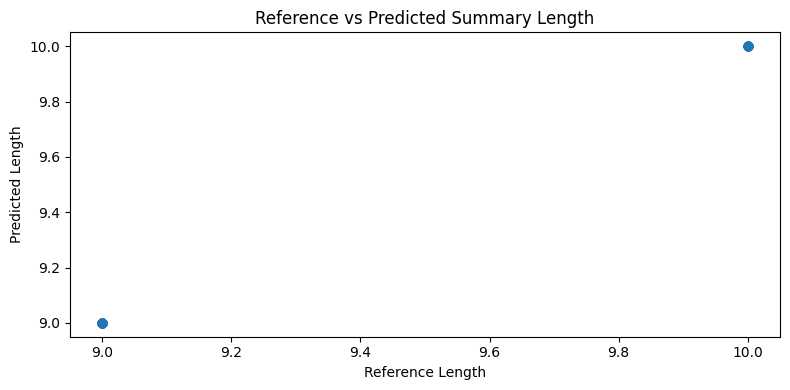

In [42]:
plt.figure(figsize=(8, 4)); plt.scatter(length_df["reference_len"], 
                                        length_df["predicted_len"], alpha=0.5); 
plt.xlabel("Reference Length"); 
plt.ylabel("Predicted Length"); 
plt.title("Reference vs Predicted Summary Length"); 
plt.tight_layout(); 
plt.show()

### **Sample Predictions Table:**

In [43]:
sample_pred_df = pd.DataFrame({"article": test_df["article_clean"].iloc[:10].tolist(), 
                               "reference_summary": test_refs[:10], 
                               "predicted_summary": test_pred_summaries[:10]}); sample_pred_df

,article,reference_summary,predicted_summary
0,the company reported a clinical study after se...,company reported a clinical study to support s...,company reported a clinical study to support i...
1,the hospital expanded a funding round after se...,hospital expanded a funding round to support i...,hospital expanded a funding round to support r...
2,the energy provider launched a safety update a...,energy provider launched a safety update to su...,energy provider launched a safety update to su...
3,the research team launched a new policy after ...,research team launched a new policy to support...,research team launched a new policy to support...
4,the startup investigated a service disruption ...,startup investigated a service disruption to s...,startup investigated a service disruption to s...
5,the startup expanded a technology roadmap afte...,startup expanded a technology roadmap to suppo...,startup expanded a technology roadmap to suppo...
6,the energy provider announced a product releas...,energy provider announced a product release to...,energy provider announced a product release to...
7,the hospital launched a clinical study after s...,hospital launched a clinical study to support ...,hospital launched a clinical study to support ...
8,the hospital reported a sustainability plan af...,hospital reported a sustainability plan to sup...,hospital reported a sustainability plan to sup...
9,the university approved a new policy after sev...,university approved a new policy to support ex...,university approved a new policy to support re...


### **Best BLEU Examples:**

In [44]:
best_idx = np.argsort(test_bleu_scores)[-10:]; best_idx

array([120, 119,  56,  58, 148,  78,  97,  96,  40, 122], dtype=int64)

### **Worst BLEU Examples:**

In [45]:
worst_idx = np.argsort(test_bleu_scores)[:10]; worst_idx

array([  0,  62,  61, 114, 115, 117, 118,  55,  54, 121], dtype=int64)

### **Error Analysis by Summary Length:**

In [46]:
error_len_df = pd.DataFrame({"bleu": test_bleu_scores, "ref_len": [len(x.split()) for x in test_refs]}); 
error_len_df.groupby(pd.cut(error_len_df["ref_len"], bins=4))["bleu"].mean()

ref_len
(8.999, 9.25]    0.808649
(9.75, 10.0]     0.801483
Name: bleu, dtype: float64

### **Token Coverage Analysis:**

In [47]:
src_coverage = np.mean([len(set(a.split())) for a in test_df["article_clean"].iloc[:100]]); 
pred_coverage = np.mean([len(set(p.split())) for p in test_pred_summaries[:100]]); 
print("Avg unique source tokens:", round(float(src_coverage), 2)); 
print("Avg unique predicted tokens:", round(float(pred_coverage), 2))

Avg unique source tokens: 42.36
Avg unique predicted tokens: 9.36


### **Save Model Artifacts:**

In [48]:
train_model_path = MODEL_DIR / "seq2seq_summarization.keras"
encoder_path = MODEL_DIR / "encoder_summarization.keras"
decoder_path = MODEL_DIR / "decoder_summarization.keras"
tokenizer_meta_path = MODEL_DIR / "tokenizer_meta.json"
seq2seq_model.save(train_model_path)
encoder_model.save(encoder_path)
decoder_model.save(decoder_path)
tokenizer_meta = {"src_vocab_size": src_vocab_size, "tgt_vocab_size": tgt_vocab_size, "max_src_len": MAX_SRC_LEN,
                  "max_tgt_len": MAX_TGT_LEN, "seed": SEED}
with open(tokenizer_meta_path, "w") as f:
    json.dump(tokenizer_meta, f, indent=4)
print(train_model_path)
print(encoder_path)
print(decoder_path)
print(tokenizer_meta_path)

C:\Users\atripathi\OneDrive - Veralto\Desktop\AI Codes\RNN\LSTM Model\Text Summarization using Seq2Seq with Attention\artifacts_lstm_summarization\models\seq2seq_summarization.keras
C:\Users\atripathi\OneDrive - Veralto\Desktop\AI Codes\RNN\LSTM Model\Text Summarization using Seq2Seq with Attention\artifacts_lstm_summarization\models\encoder_summarization.keras
C:\Users\atripathi\OneDrive - Veralto\Desktop\AI Codes\RNN\LSTM Model\Text Summarization using Seq2Seq with Attention\artifacts_lstm_summarization\models\decoder_summarization.keras
C:\Users\atripathi\OneDrive - Veralto\Desktop\AI Codes\RNN\LSTM Model\Text Summarization using Seq2Seq with Attention\artifacts_lstm_summarization\models\tokenizer_meta.json


### **Reload Training Model for Sanity Check:**

In [49]:
reloaded_train_model = tf.keras.models.load_model(train_model_path); sanity_pred = reloaded_train_model.predict([X_test_pad[:2], 
                                                                                                                 decoder_input_test[:2]], 
                                                                                                                verbose=0); sanity_pred.shape

(2, 11, 57)

### **Final Metrics Summary Table:**

In [50]:
summary_table = pd.DataFrame({"Metric": ["Validation BLEU-like", "Test BLEU-like", "Exact Match Ratio", 
                                         "Source Vocab Size", "Target Vocab Size"], 
                              "Value": [np.mean(val_bleu_scores), np.mean(test_bleu_scores), 
                                        exact_match, src_vocab_size, tgt_vocab_size]}); summary_table

,Metric,Value
0,Validation BLEU-like,0.814732
1,Test BLEU-like,0.806260
2,Exact Match Ratio,0.126667
3,Source Vocab Size,88.000000
4,Target Vocab Size,57.000000


### **Project Summary**

This project presents a complete implementation of an **Abstractive Text Summarization System using Seq2Seq with Attention**, focusing on generating summaries from long documents.

The workflow begins with preprocessing textual data, including tokenization, vocabulary building, and sequence padding.

The core of the system is a **Seq2Seq Encoder–Decoder Model with Attention**, which consists of:

### **1. Encoder**

- Processes input document  
- Encodes context into hidden representation  

### **2. Attention Mechanism**

- Focuses on relevant parts of the document  
- Improves context understanding  

### **3. Decoder**

- Generates summary text  
- Produces output word-by-word  

The model learns:
- semantic relationships  
- contextual importance  
- language generation patterns  

The architecture includes:
- embedding layers  
- LSTM layers  
- attention layer  
- dense output layer  

A key strength of this project is:

- **Abstractive summarization**
  - generates new text rather than extracting  

- **Attention-based learning**
  - improves summary quality  

Evaluation is performed using:

- ROUGE scores  
- qualitative evaluation  

The system can be used in real-world applications to:

- summarize documents  
- extract key insights  
- improve information accessibility  

Overall, this project demonstrates advanced NLP capabilities and showcases the ability to build **generative text summarization systems using deep learning**.

### **Key Highlights**

- Built an **Abstractive Text Summarization system using Seq2Seq with Attention**, targeting generative NLP applications.

- Addressed complex problem:
  - generating summaries from long documents  

- Utilized dataset with:
  - document-summary pairs  

- Implemented a complete **text preprocessing pipeline**, including:
  - tokenization  
  - vocabulary creation  
  - sequence preparation  

- Designed an **Encoder–Decoder architecture with Attention**, enabling:
  - context-aware text generation  

- Leveraged **embedding layers**, enabling:
  - semantic representation of words  

- Used **LSTM networks**, enabling:
  - modeling of sequential dependencies  

- Integrated **attention mechanism**, enabling:
  - focusing on important parts of text  

- Developed a **summarization system**, capable of:
  - generating meaningful summaries  
  - capturing key information  

- Evaluated model performance using:
  - ROUGE scores  

- Enabled **real-world applications**, including:
  - news summarization  
  - document analysis  
  - research assistance  

- Designed for **deployment scenarios**, including:
  - summarization APIs  
  - document intelligence systems  

- Demonstrates strong expertise in:
  - **natural language processing (NLP)**  
  - **text generation**  
  - **attention mechanisms**